# Quiz 4

## Estudio de caso: ShopEase Inc.
ShopEase Inc. es una empresa minorista en línea que ha estado en funcionamiento durante los últimos 5 años. La gerencia se centra en dos objetivos clave:
- Prever las ventas futuras para optimizar el inventario y las estrategias de marketing.
- Entender cómo la satisfacción del cliente afecta el LTV.

Para lograr estos objetivos, ShopEase ha proporcionado dos conjuntos de datos:
- ecommerce_sales_data.csv: Datos de ventas mensuales de los últimos 5 años.
- customer_satisfaction_data.csv: Indicadores de satisfacción del cliente de una muestra de 500 clientes.

La gerencia quiere que los ayude a:
- Prever las ventas para los próximos 12 meses.
- Crear un modelo de ecuación estructural (SEM) para comprender cómo la satisfacción del cliente se ve influenciada por el tiempo de respuesta, la calidad del producto y la probabilidad de recomendación, y cómo estos factores afectan los ingresos de la empresa.

### Pregunta 1: Pronóstico de Ventas para ShopEase Inc. 

Objetivo: ShopEase quiere saber cuántas ventas puede esperar en los próximos 12 meses para planificar su inventario y campañas de marketing.

Instrucciones:
- Utiliza el archivo ecommerce_sales_data.csv que contiene las ventas mensuales de los últimos 5 años.
- Crea un modelo de series temporales usando la librería auto_ts para predecir las ventas mensuales durante los próximos 12 meses.
- Visualiza las predicciones en un gráfico junto con los datos históricos.
- Explica tus conclusiones sobre el comportamiento esperado de las ventas en el próximo año.

### Pregunta 2: Modelado de Ecuaciones Estructurales (SEM)
Objetivo: ShopEase quiere entender mejor cómo los diferentes factores de satisfacción del cliente (tiempo de respuesta, calidad del producto y probabilidad de recomendación) afectan el valor total esperado de vida de un cliente (LTV).

Instrucciones:
- Utiliza el archivo customer_satisfaction_data.csv que contiene los indicadores de satisfacción del cliente.
- Define las siguientes relaciones en un modelo SEM:
    - Confianza del cliente como variable latente, medida por el tiempo de respuesta, calidad del producto, y probabilidad de recomendación.
- Ajusta el modelo y explica los coeficientes de las relaciones entre las variables.
- Proporciona conclusiones sobre larelación que tiene la satisfacción del cliente con el valor de vida del cliente en ShopEase.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from auto_ts import auto_timeseries

Imported auto_timeseries version:0.0.92. Call by using:
model = auto_timeseries(score_type='rmse',
        time_interval='M', non_seasonal_pdq=None, seasonality=False,
        seasonal_period=12, model_type=['best'], verbose=2, dask_xgboost_flag=0)
model.fit(traindata, ts_column,target)
model.predict(testdata, model='best')



## Parte uno

In [4]:
!pip install auto-ts

In [14]:
df = pd.read_csv('ecommerce_sales_data.csv', parse_dates=['Fecha'])
df.set_index('Fecha', inplace=True)
df.head(3)

,Ventas
Fecha,
2019-10-31 11:48:50.173779,3929.298727
2019-11-30 11:48:50.173779,4250.388935
2019-12-31 11:48:50.173779,5295.721284


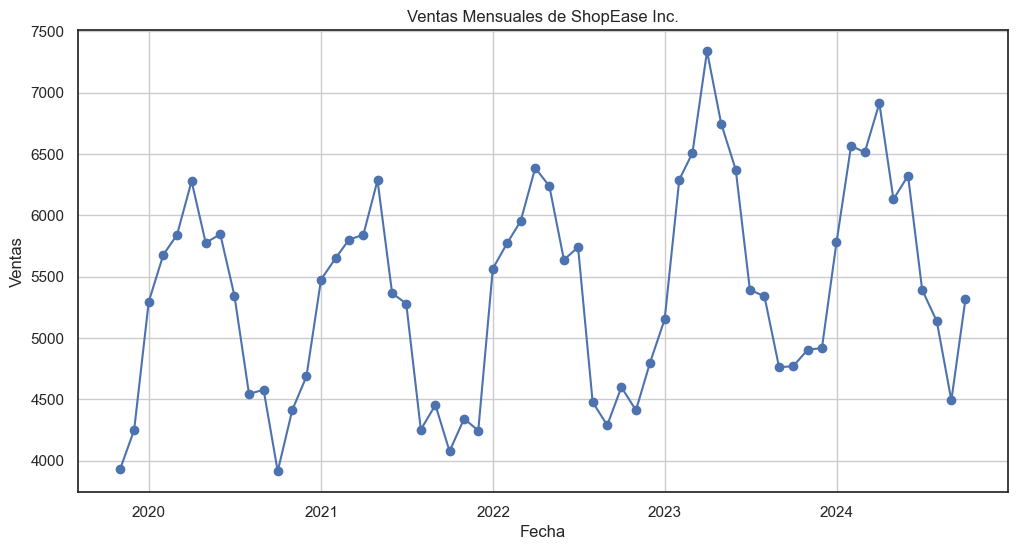

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Ventas'], marker='o')
plt.title('Ventas Mensuales de ShopEase Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

In [16]:
model = auto_timeseries(
    score_type='rmse',       # Métrica de evaluación
    time_interval='M',       # Intervalo mensual
    non_seasonal_pdq=None,   # Para modelos SARIMAX
    seasonality=False,       # Deshabilitar búsqueda de estacionalidad (se puede cambiar)
    model_type='best',       # Seleccionar el mejor modelo
    verbose=2                # Nivel de verbosidad
)

Start of Fit.....
    Target variable given as = Ventas
Start of loading of data.....
    Inputs: ts_column = Fecha, sep = ,, target = ['Ventas']
    Using given input: pandas dataframe...
    train time series Fecha column is the index on test data...
    train data shape = (48, 1)
Alert: Could not detect strf_time_format of Fecha. Provide strf_time format during "setup" for better results.
setting maxlag to a low number = 5

Running Augmented Dickey-Fuller test with paramters:
    maxlag: 5 regression: c autolag: BIC
Data is already stationary
There is no differencing needed in this datasets for VAR model


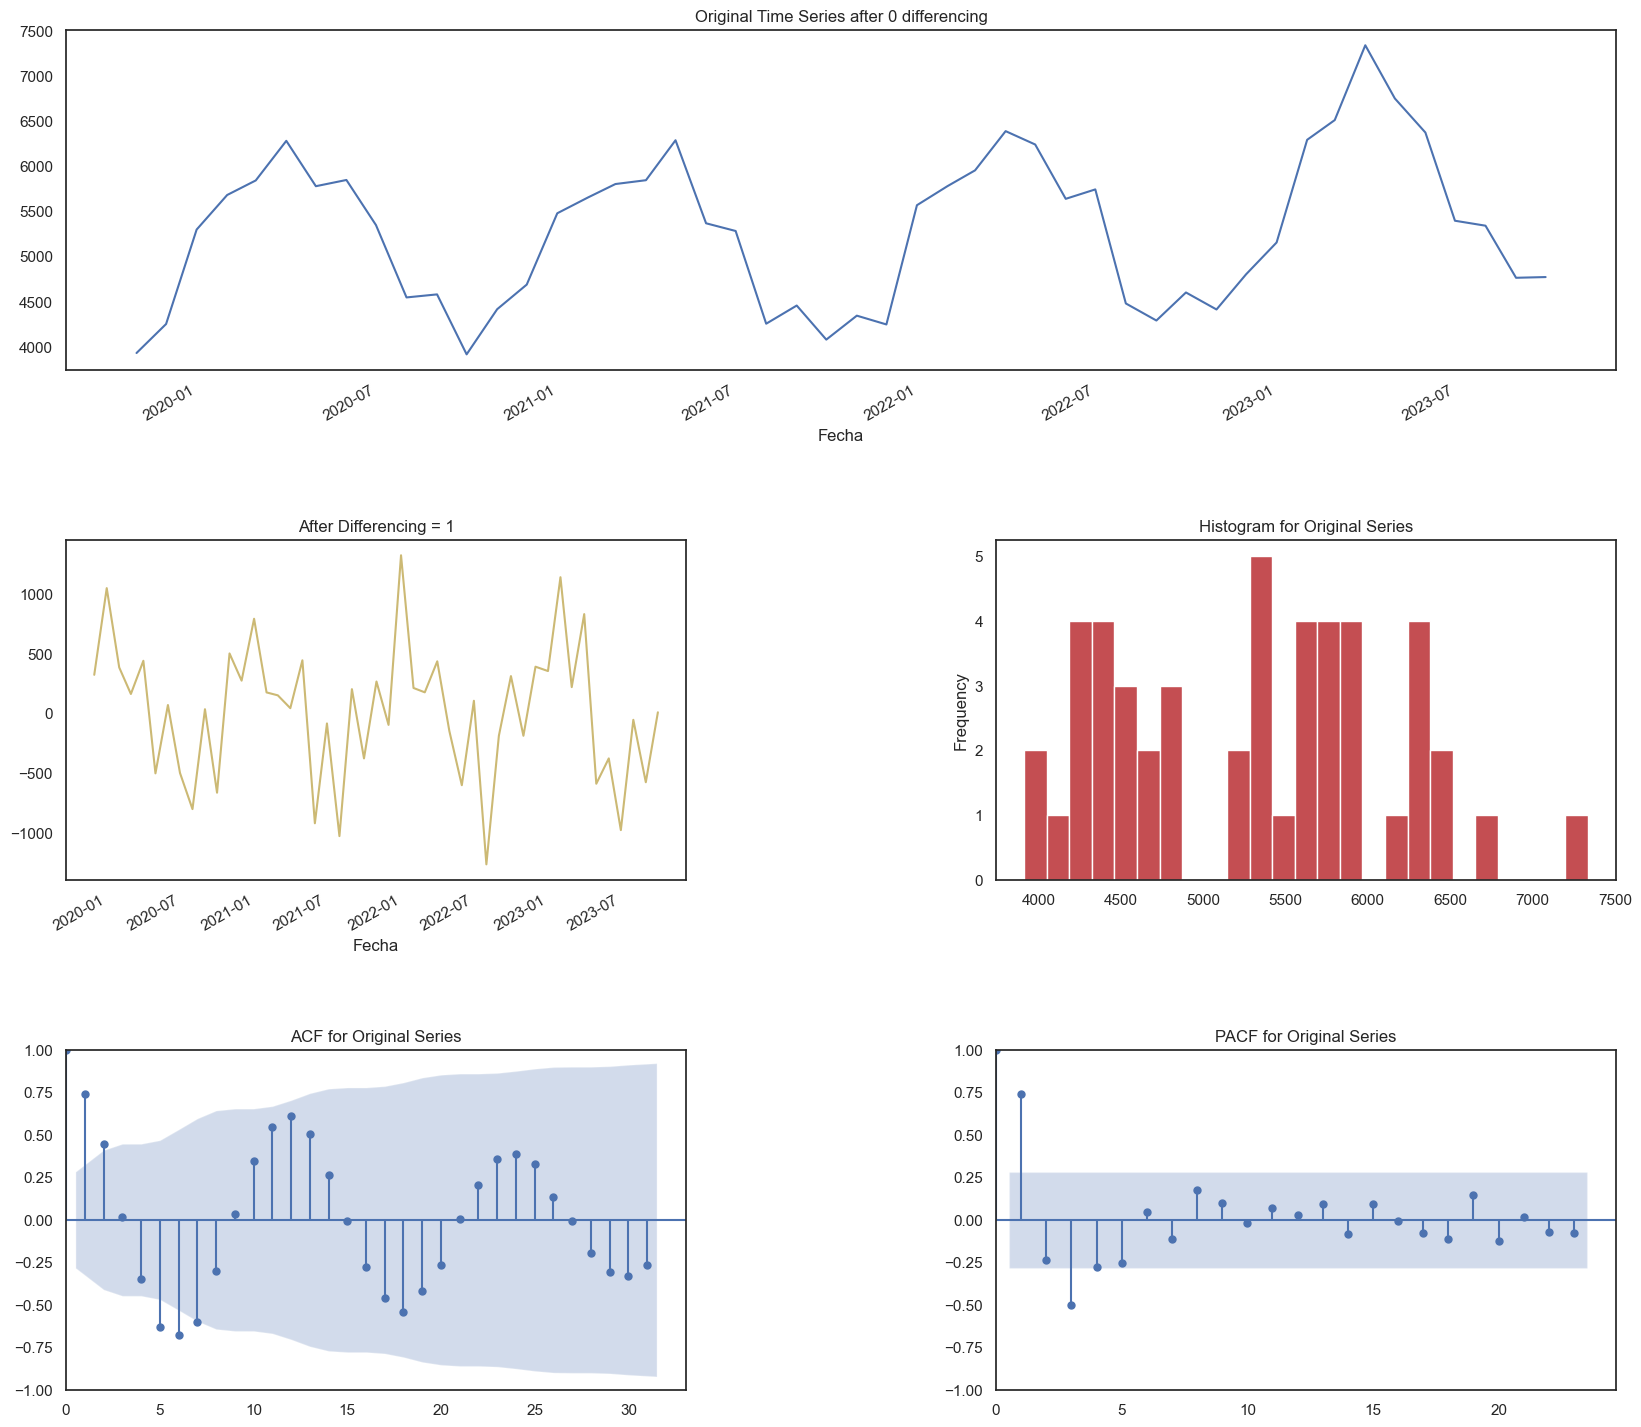

Time Interval is given as M
    Correct Time interval given as a valid Pandas date-range frequency...


Building Prophet Model



Running Facebook Prophet Model...
kwargs for Prophet model: {'iter': 100}
    Fit-Predict data (shape=(48, 2)) with Confidence Interval = 0.95...
  Starting Prophet Fit
      No seasonality assumed since seasonality flag is set to False
  Starting Prophet Cross Validation
Max. iterations using expanding window cross validation = 5

Fold Number: 1 --> Train Shape: 23 Test Shape: 5


20:26:13 - cmdstanpy - INFO - Chain [1] start processing
20:26:13 - cmdstanpy - INFO - Chain [1] done processing
20:26:13 - cmdstanpy - INFO - Chain [1] start processing


    RMSE = 823.24
    Std Deviation of actuals = 718.07
    Normalized RMSE (as pct of std dev) = 115%
Cross Validation window: 1 completed

Fold Number: 2 --> Train Shape: 28 Test Shape: 5


20:26:14 - cmdstanpy - INFO - Chain [1] done processing


    RMSE = 548.33
    Std Deviation of actuals = 285.19
    Normalized RMSE (as pct of std dev) = 192%
Cross Validation window: 2 completed

Fold Number: 3 --> Train Shape: 33 Test Shape: 5


...

20:26:17 - cmdstanpy - INFO - Chain [1] start processing
20:26:18 - cmdstanpy - INFO - Chain [1] done processing


    RMSE = 645.32
    Std Deviation of actuals = 586.79
    Normalized RMSE (as pct of std dev) = 110%
Cross Validation window: 5 completed

-------------------------------------------
Model Cross Validation Results:
-------------------------------------------
    MAE (Mean Absolute Error = 501.05
    MSE (Mean Squared Error = 349178.46
    MAPE (Mean Absolute Percent Error) = 10%
    RMSE (Root Mean Squared Error) = 590.9132
    Normalized RMSE (MinMax) = 18%
    Normalized RMSE (as Std Dev of Actuals)= 65%
Time Taken = 6 seconds


20:26:19 - cmdstanpy - INFO - Chain [1] start processing
20:26:19 - cmdstanpy - INFO - Chain [1] done processing


  End of Prophet Fit


Building Auto SARIMAX Model



Running Auto SARIMAX Model...


Best Parameters:
p: None, d: None, q: None
P: None, D: None, Q: None
Seasonality: False
Seasonal Period: 12

Fold Number: 1 --> Train Shape: 23 Test Shape: 5

    Finding the best parameters using AutoArima:
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=461.002, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=437.043, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=364.171, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=365.671, Time=0.36 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=358.541, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=359.763, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=359.939, Time=0.20 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,3)(0,0,0)[0]  

 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=643.333, Time=0.33 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=649.841, Time=0.12 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=669.642, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=673.051, Time=0.14 sec

Best model:  ARIMA(3,0,1)(0,0,0)[0] intercept
Total fit time: 4.529 seconds

Best model is a Seasonal SARIMAX(3,0,1)*(0,0,0,12), aic = 643.333
Static Forecasts:
    RMSE = 970.23
    Std Deviation of Actuals = 586.79
    Normalized RMSE (as pct of std dev) = 165.3%

SARIMAX RMSE (all folds): 603.4644
SARIMAX Norm RMSE (all folds): 73%


-------------------------------------------
Model Cross Validation Results:
-------------------------------------------
    MAE (Mean Absolute Error = 528.53
    MSE (Mean Squared Error = 420458.01
    MAPE (Mean Absolute Percent Error) = 10%
    RMSE (Root Mean Squared Error) = 648.4273
    Normalized RMSE (MinMax) = 20%
    Normalized RMSE (as Std Dev of Actuals)= 71%

    Finding the best param

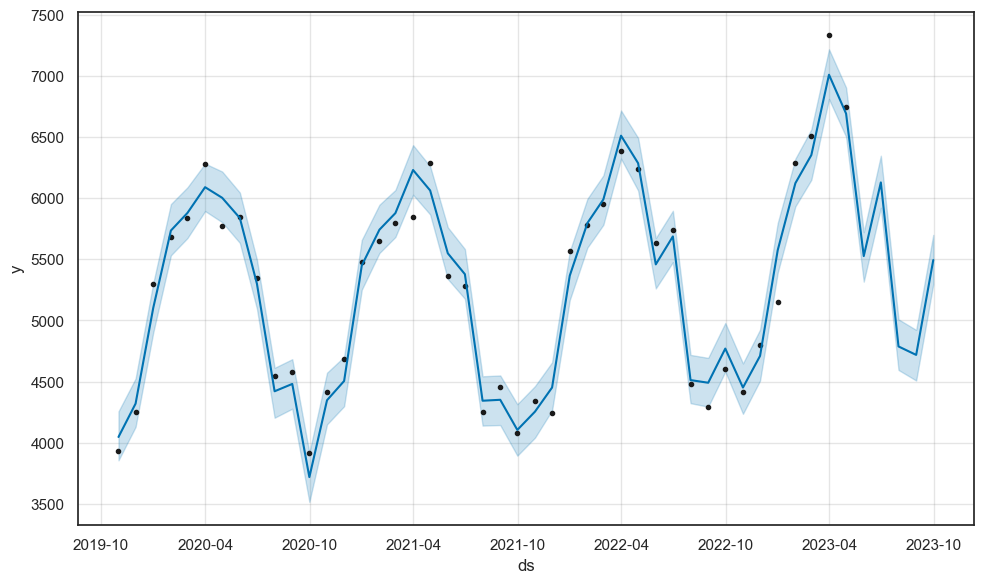

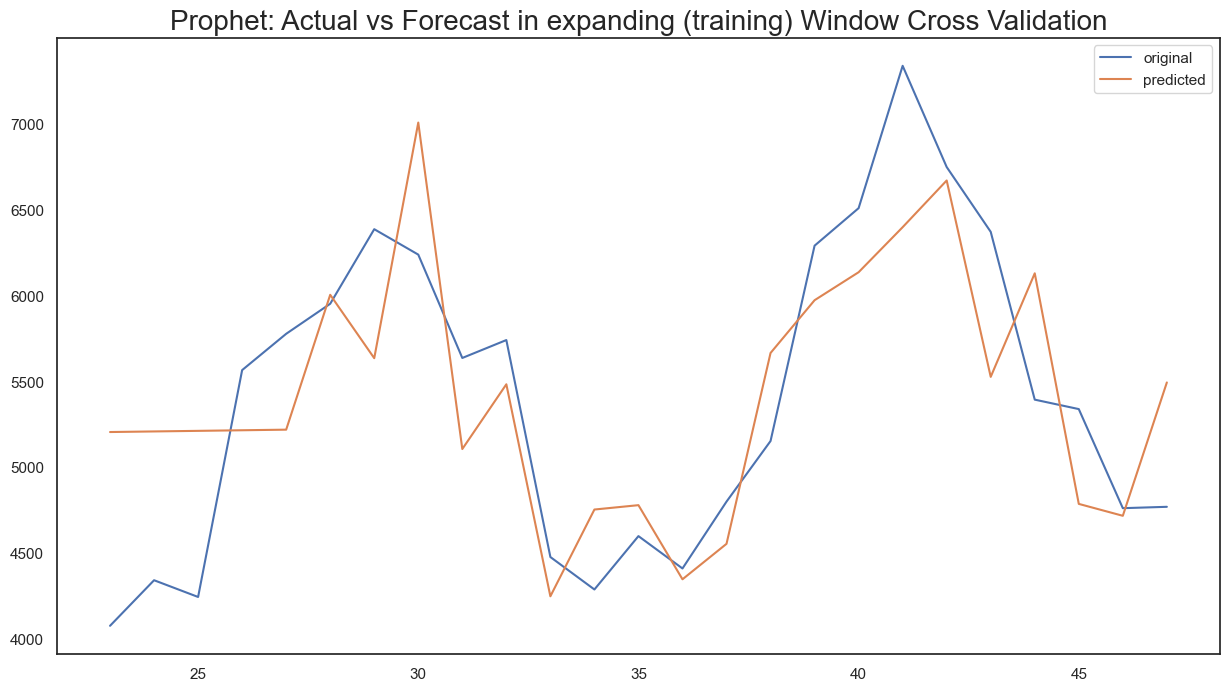

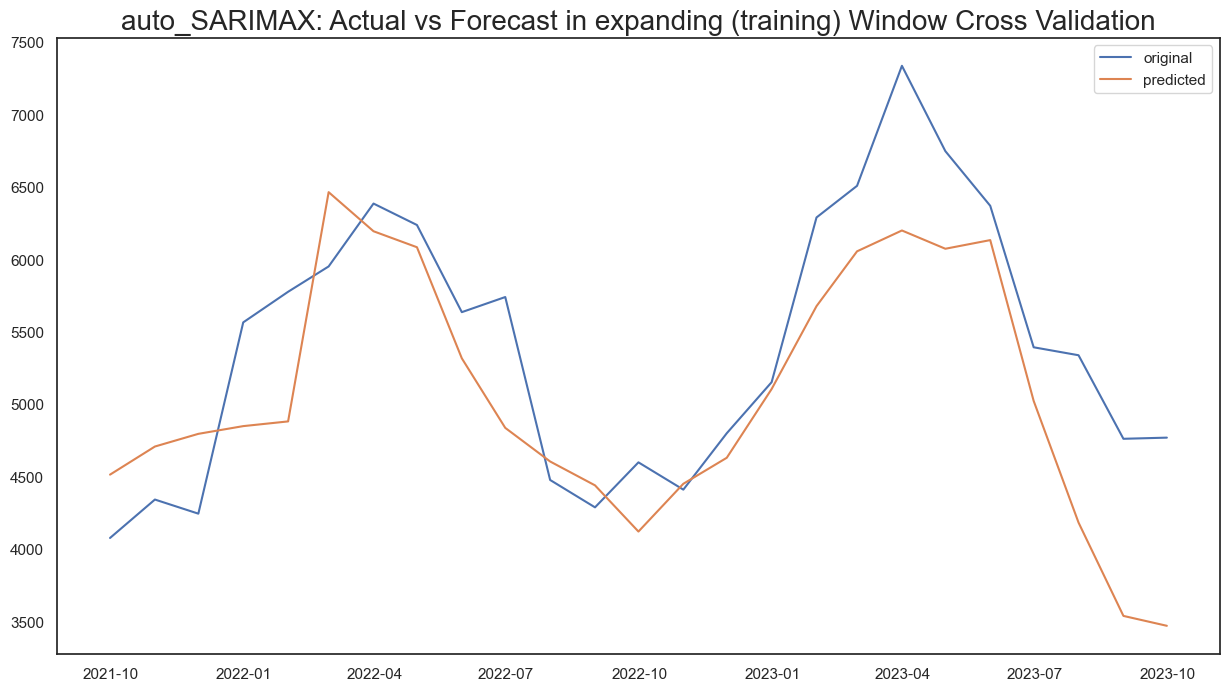

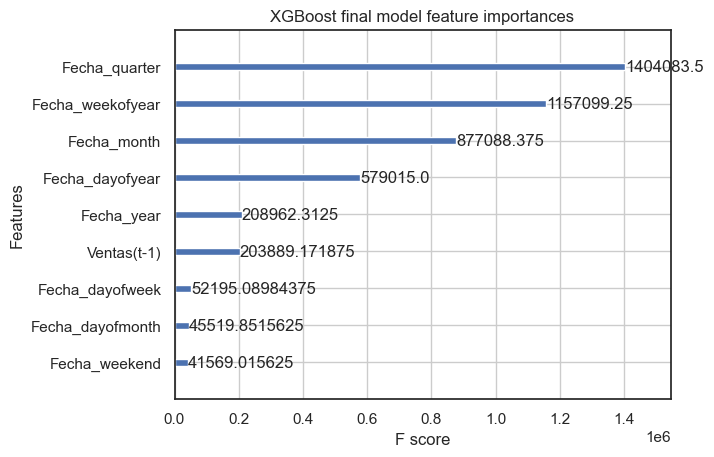

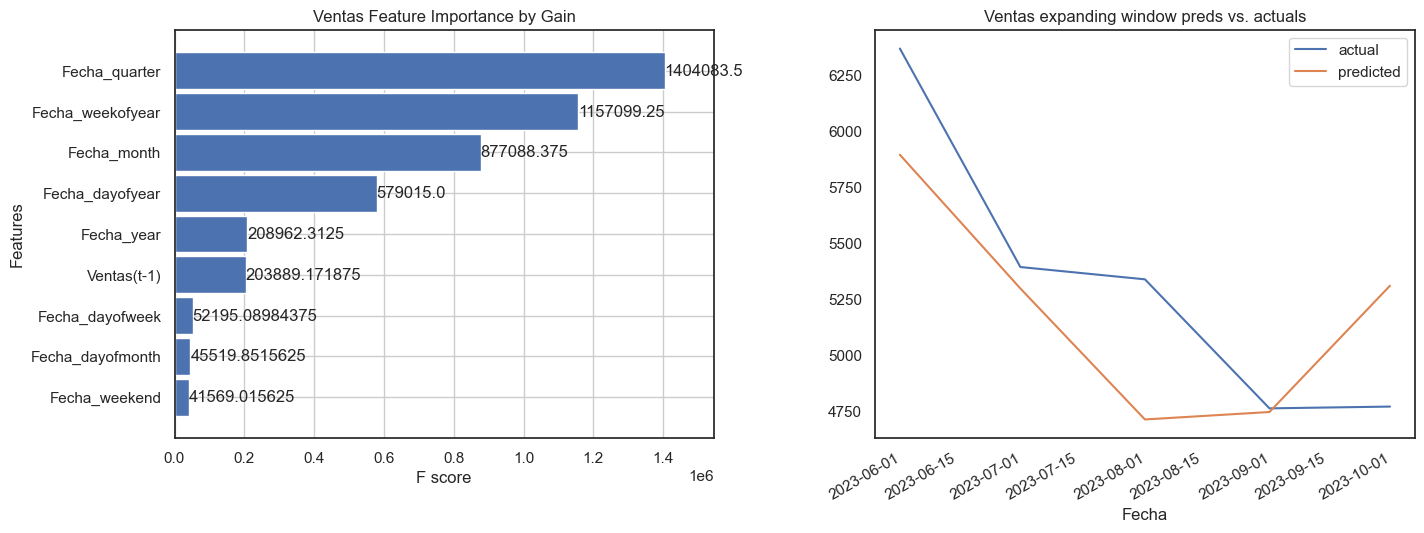

In [17]:
train_size = int(0.8 * len(df))
train_df = df[:train_size]
test_df = df[train_size:]

model.fit(
    traindata=train_df,
    ts_column=train_df.index.name,
    target='Ventas'
)

In [18]:
forecast = model.predict(testdata=test_df)
forecast

Predicting using test dataframe shape = (12, 1) for ML model
For large datasets: ML predictions will take time since it has to predict each row and use that for future predictions...
    Using given input: pandas dataframe...
    Alert: No strf_time_format given for Fecha. Provide strf_time format during "setup" for better results.
ML predictions completed


,yhat,mean_se,mean_ci_lower,mean_ci_upper
Fecha,,,,
2023-10-31 11:48:50.173779,4667.388672,NaN,NaN,NaN
2023-11-30 11:48:50.173779,4744.833984,NaN,NaN,NaN
2023-12-31 11:48:50.173779,5334.534180,NaN,NaN,NaN
2024-01-31 11:48:50.173779,6224.232422,NaN,NaN,NaN
2024-02-29 11:48:50.173779,6538.482422,NaN,NaN,NaN
2024-03-31 11:48:50.173779,6645.016113,NaN,NaN,NaN
2024-04-30 11:48:50.173779,6352.039551,NaN,NaN,NaN
2024-05-31 11:48:50.173779,6296.886230,NaN,NaN,NaN
2024-06-30 11:48:50.173779,5915.802734,NaN,NaN,NaN


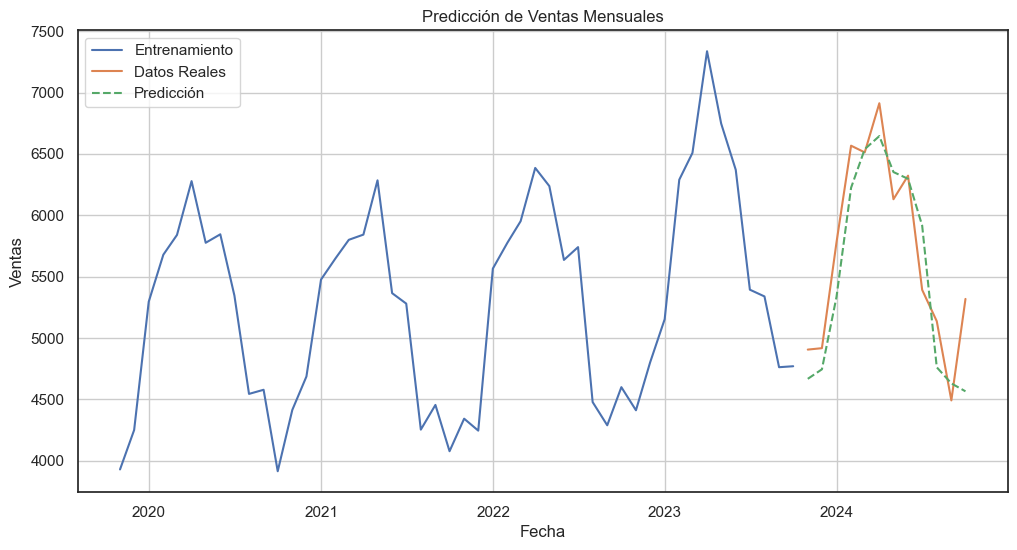

In [19]:
plt.figure(figsize=(12,6))
plt.plot(train_df.index, train_df['Ventas'], label='Entrenamiento')
plt.plot(test_df.index, test_df['Ventas'], label='Datos Reales')
plt.plot(test_df.index, forecast['yhat'], label='Predicción', linestyle='--')
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(test_df['Ventas'], forecast['yhat'], squared=False)
print(f'RMSE en el conjunto de prueba: {rmse:.2f}')

RMSE en el conjunto de prueba: 356.36


### Predicción Futura

Predicting using test dataframe shape = (12, 0) for ML model
For large datasets: ML predictions will take time since it has to predict each row and use that for future predictions...
    Using given input: pandas dataframe...
    Alert: No strf_time_format given for Fecha. Provide strf_time format during "setup" for better results.
    converting testdata to datetime index erroring. Please check input and try again.
ML predictions completed


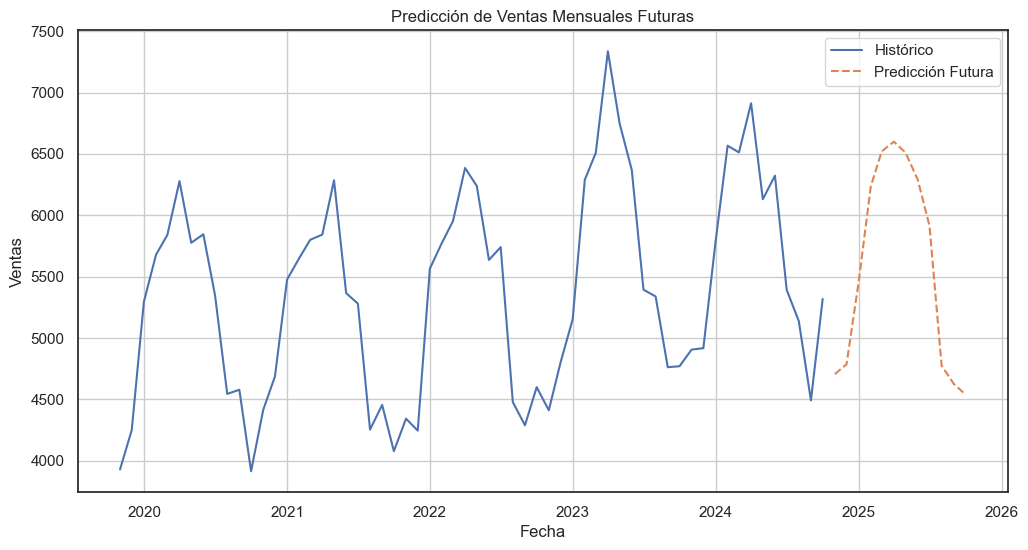

In [21]:
future_periods = 12
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_periods, freq='M')

future_df = pd.DataFrame(index=future_dates)
future_forecast = model.predict(testdata=future_df)

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Ventas'], label='Histórico')
plt.plot(future_dates, future_forecast['yhat'], label='Predicción Futura', linestyle='--')
plt.title('Predicción de Ventas Mensuales Futuras')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

Notamos que se va a volver algo estacional y va a seguir cierto patrón, por consecuencia va a subir por ahí de inicio de año y a medidados de año empieza a bajar otra vez

## Parte dos

In [25]:
import pandas as pd
import numpy as np
from semopy import Model, Optimizer
import matplotlib.pyplot as plt
from semopy import Model, Optimizer

# Definir el modelo SEM usando la notación estándar de SEM
model_desc = """
# Latent Variables
Desconfianza =~ Tiempo_Respuesta + Calidad_Producto + Probabilidad_Recomendacion
"""

In [24]:
dr = pd.read_csv('customer_satisfaction_data.csv')
dr.head(3)

,Tiempo_Respuesta,Calidad_Producto,Probabilidad_Recomendacion,LTV
0,7.993428,9.389266,7.402641,1156.97
1,6.723471,10.000000,7.562898,1324.58
2,8.295377,5.902149,5.911942,711.72


In [32]:
from sklearn.preprocessing import StandardScaler
# Crear un objeto StandardScaler
scaler = StandardScaler()
# Seleccionar solo las columnas numéricas
columnas_numericas = dr.select_dtypes(include=['float64', 'int64']).columns

# Aplicar el scaler a todas las columnas numéricas
dr[columnas_numericas] = scaler.fit_transform(dr[columnas_numericas])

In [33]:
mod = Model(model_desc)
res_opt = mod.fit(dr)
estimates = mod.inspect()

print(estimates)

                         lval  op                        rval  Estimate  \
0            Tiempo_Respuesta   ~       Confianza_del_cliente  1.000000   
1            Calidad_Producto   ~       Confianza_del_cliente -0.141327   
2  Probabilidad_Recomendacion   ~       Confianza_del_cliente -1.299332   
3       Confianza_del_cliente  ~~       Confianza_del_cliente  0.543099   
4            Calidad_Producto  ~~            Calidad_Producto  0.989200   
5  Probabilidad_Recomendacion  ~~  Probabilidad_Recomendacion  0.083047   
6            Tiempo_Respuesta  ~~            Tiempo_Respuesta  0.456705   

   Std. Err    z-value   p-value  
0         -          -         -  
1   0.06332  -2.231957  0.025618  
2  0.538484  -2.412946  0.015824  
3   0.23091   2.351998  0.018673  
4  0.062722  15.771129       0.0  
5  0.378129   0.219627  0.826161  
6  0.225808   2.022531  0.043122  


### Análisis del Modelo SEM y Resultados

Variables latentes (**Tiempo_Respuesta**, **Calidad_Producto** y **Probabilidad_Recomendacion**) sobre la **Desconfianza del cliente**

#### Estimaciones de Parámetros

1. **Relaciones entre Variables Latentes y Observadas**:
   - **Tiempo_Respuesta** (Desconfianza del cliente): Establecido como referencia con un valor de 1.0 (por convención en SEM).
   - **Calidad_Producto** (Desconfianza del cliente): Estima una carga factorial de **-0.141**, en este caso estas variables afectan de manera negativa la desconfianza generando en su lugar confianza con el cliente
   - **Probabilidad_Recomendacion** (Desconfianza del cliente): Tiene una carga factorial de **-1.299**, lo mismo ocurre aquí pero en mayor medida, si la recomendación aumenta la desconfianza disminuye generando confianza.



In [36]:
# Cargar factores estimados (cargas factoriales)
confianza_factors = [1.0,  -0.141, -1.299]  # Uso, Seguridad, Recomendaciones

# Función para calcular el valor de la variable latente
def calculate_latent_values(df):
    # Calcular Confianza como la suma ponderada de Uso, Seguridad y Recomendaciones
    df['Desconfianza'] = (df['Tiempo_Respuesta'] * confianza_factors[0] +
                       df['Calidad_Producto'] * confianza_factors[1] +
                       df['Probabilidad_Recomendacion'] * confianza_factors[2])
    
    return df[['Desconfianza']]

# Calcular valores latentes en el dataset
latent_values = calculate_latent_values(dr)

# Mostrar los primeros valores calculados
print(latent_values.head())

   Desconfianza
0     -0.300309
1     -1.206726
2      1.577300
3      3.631582
4     -0.881350
